In [7]:
# Zajęcia 2

In [8]:
# Przygotowanie danych

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienie stylu wykresów
sns.set_theme(style="whitegrid")

# 1. Wczytanie danych
# Zbiór na Kaggle po pobraniu zazwyczaj nazywa się 'CC GENERAL.csv'
df = pd.read_csv('CC GENERAL.csv')

# 2. Sprawdzenie struktury danych
print("Struktura danych (wiersze, kolumny):", df.shape)
df.info()

# Usunięcie CUST_ID (zgodnie z obietnicą z proposalu, to tylko identyfikator)
df = df.drop('CUST_ID', axis=1)

# 3. Identyfikacja brakujących wartości
print("\nBrakujące wartości w kolumnach:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 4. Imputacja brakujących wartości
# Z racji finansowego charakteru danych i obecności wartości odstających, 
# bezpieczniej jest użyć mediany zamiast średniej do uzupełnienia braków.
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

# 5. Usunięcie duplikatów (profilaktycznie)
duplikaty = df.duplicated().sum()
print(f"\nLiczba duplikatów: {duplikaty}")
df = df.drop_duplicates()

Struktura danych (wiersze, kolumny): (8950, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX     

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


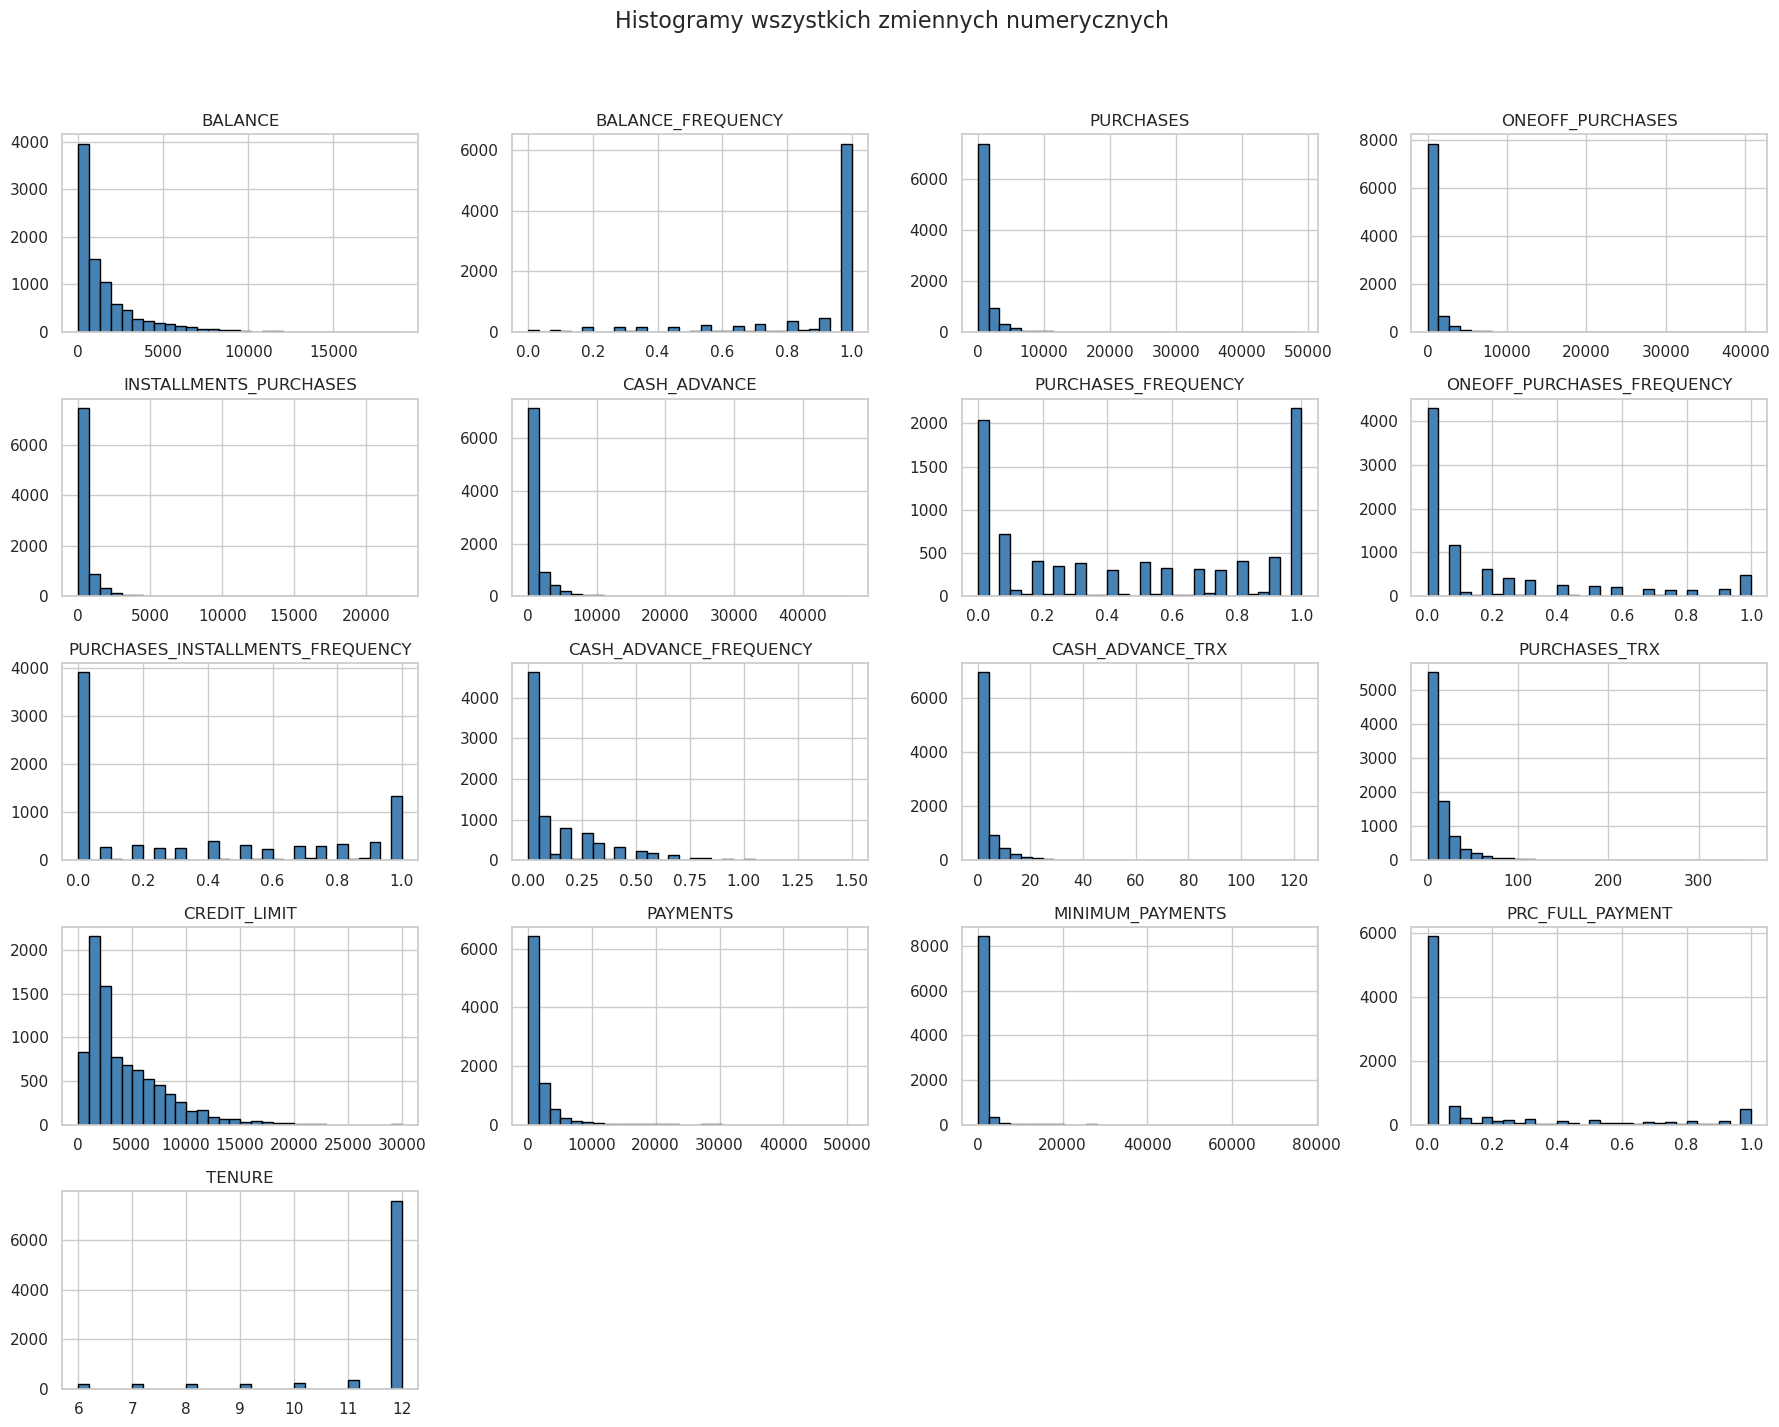

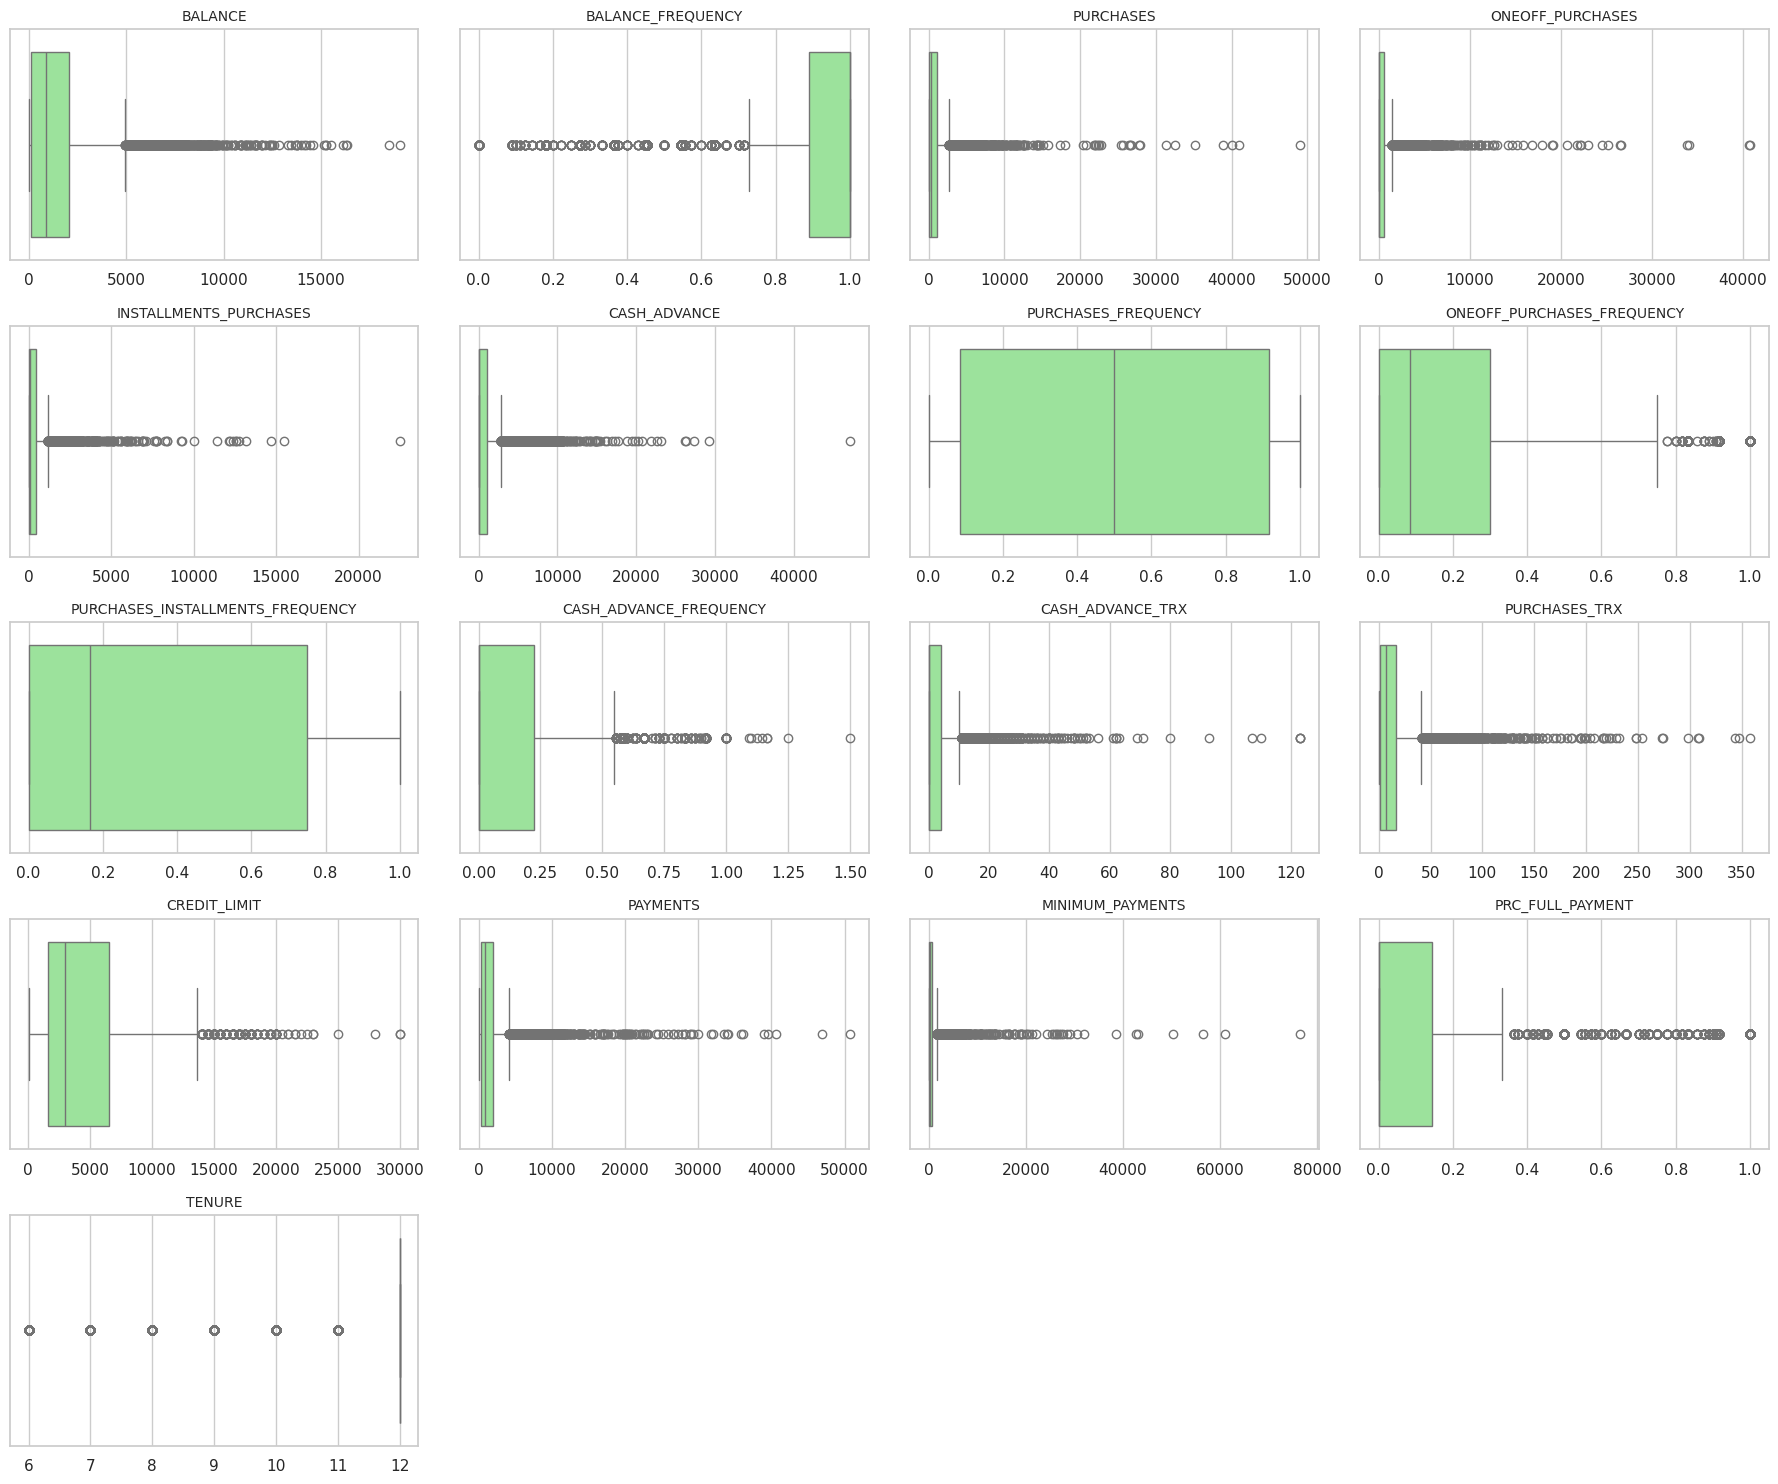

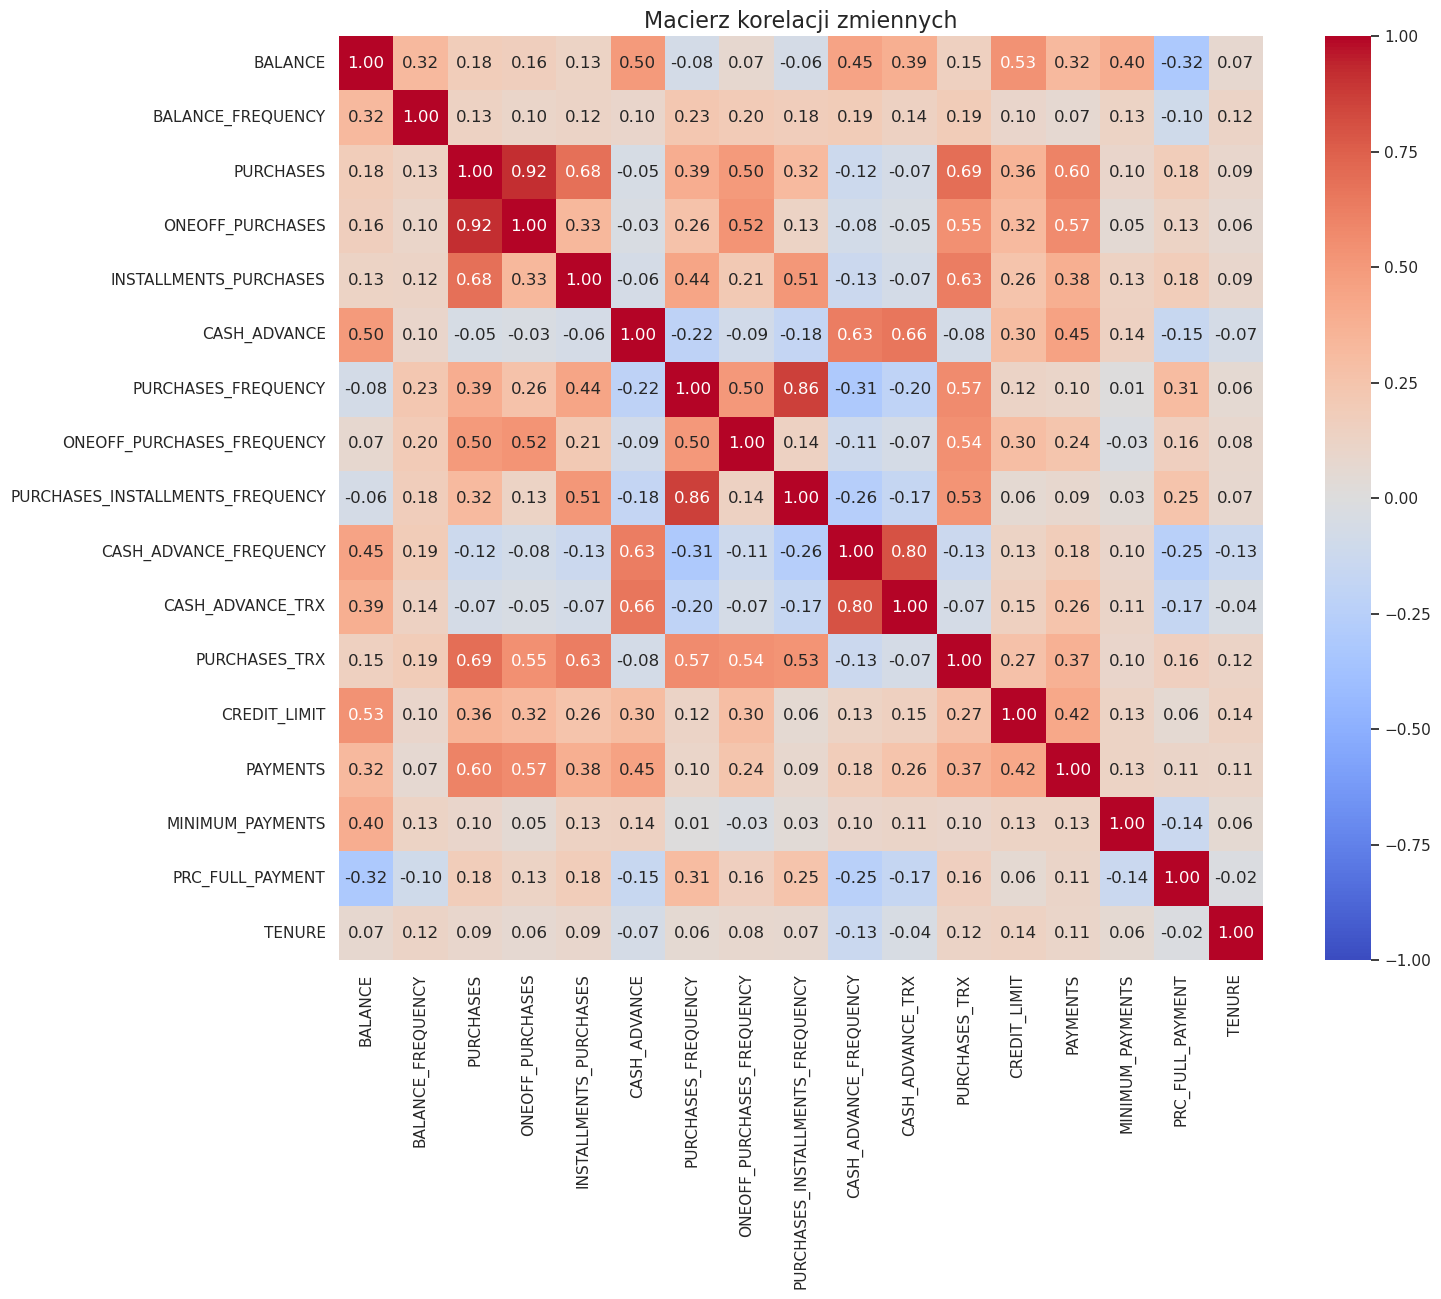

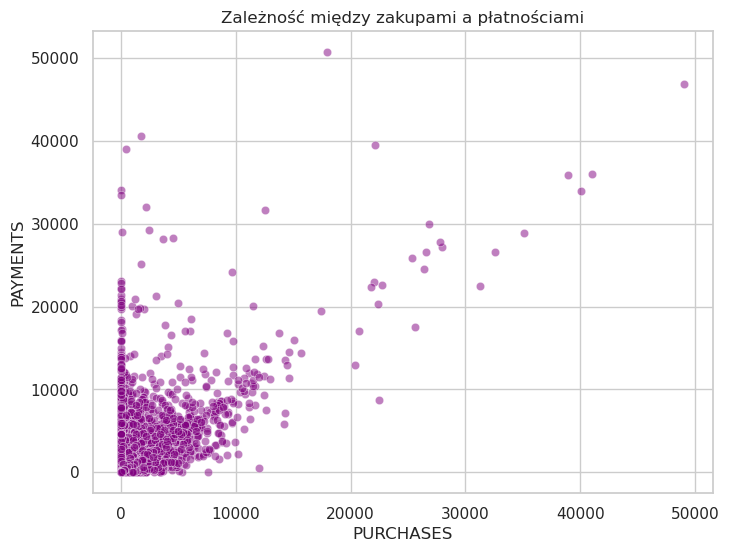

In [9]:
# Eksploracyjna analiza danych (EDA) i Wizualizacja

# --- EDA: Statystyki opisowe ---
display(df.describe().T)

# --- WIZUALIZACJE ---

# 1. Histogramy (Rozkłady zmiennych)
# Pozwolą sprawdzić czy dane mają rozkład normalny (odpowiedź: nie, będą mocno skośne prawostronnie)
df.hist(figsize=(18, 15), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Histogramy wszystkich zmiennych numerycznych', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2. Wykresy pudełkowe (Boxploty - Identyfikacja wartości odstających)
# Rysujemy osobne wykresy ze względu na różną skalę zmiennych
plt.figure(figsize=(18, 15))
for i, col in enumerate(df.columns, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(col, fontsize=10)
    plt.xlabel('')
plt.tight_layout()
plt.show()

# 3. Macierz korelacji (Heatmapa - Zależności między zmiennymi)
plt.figure(figsize=(16, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Macierz korelacji zmiennych', fontsize=16)
plt.show()

# 4. Wykres rozrzutu (Scatter plot)
# Przykładowy wykres dla pary silnie skorelowanych lub biznesowo ważnych zmiennych
# Np. PURCHASES (Zakupy) vs PAYMENTS (Spłaty)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PURCHASES', y='PAYMENTS', data=df, alpha=0.5, color='purple')
plt.title('Zależność między zakupami a płatnościami')
plt.xlabel('PURCHASES')
plt.ylabel('PAYMENTS')
plt.show()

In [10]:
# # Wstępne obserwacje
# #. Jakie są podstawowe charakterystyki danych?
# Zbiór danych składa się z 8950 obserwacji. Po usunięciu identyfikatora klienta (CUST_ID, typ object), w zbiorze pozostało 17 zmiennych numerycznych (typy float64 i int64).
# Analiza statystyk opisowych wykazuje ogromną wariancję (odchylenie standardowe często przewyższa średnią, np. dla PURCHASES średnia wynosi ok. 1003, a odchylenie standardowe aż 2136).
# Zmienne operują na skrajnie różnych rzędach wielkości – od zmiennych ułamkowych określających częstotliwość (np. BALANCE_FREQUENCY w przedziale 0-1) po kwoty rzędu kilkudziesięciu tysięcy dolarów (np. maksymalny BALANCE to 19043, a PURCHASES to 49039).
# 2. Czy w danych występują braki lub anomalie?
# Braki danych: Zidentyfikowano niewielką liczbę braków w kolumnach MINIMUM_PAYMENTS (313 braków, ok. 3.5% zbioru) oraz CREDIT_LIMIT (1 brak). Ze względu na silną asymetrię rozkładów, najbezpieczniejszym podejściem była imputacja tych wartości za pomocą mediany.
# Anomalie i rozkłady: Histogramy pokazują, że niemal wszystkie zmienne finansowe (saldo, zakupy, wypłaty gotówkowe) mają silnie prawoskośny rozkład. Większość klientów generuje małe obroty, ale istnieje wąska grupa "wielorybów" generujących ogromne koszty.
# Wartości odstające (Outliers): Wykresy pudełkowe (boxplots) ujawniają masową obecność wartości odstających w górnych rejestrach dla większości zmiennych (szczególnie PURCHASES, MINIMUM_PAYMENTS, PAYMENTS). Nie są to błędy danych, lecz naturalna charakterystyka danych finansowych (bardzo bogaci klienci).
# 3. Czy widoczne są zależności między zmiennymi?
# Tak, macierz korelacji (heatmapa) wyraźnie wskazuje na obecność silnych zależności liniowych. Najważniejsze z nich to:
# PURCHASES i ONEOFF_PURCHASES (0.92) – bardzo silna korelacja, wynikająca wprost z faktu, że jednorazowe zakupy są główną składową całkowitych zakupów.
# PURCHASES_FREQUENCY i PURCHASES_INSTALLMENTS_FREQUENCY (0.86) – klienci często kupujący, zazwyczaj robią to na raty.
# CASH_ADVANCE_TRX i CASH_ADVANCE_FREQUENCY (0.80) – liczba transakcji gotówkowych jest wprost proporcjonalna do częstotliwości ich pobierania.
# PURCHASES i PAYMENTS (0.60) – wykres rozrzutu dla tej pary potwierdza pozytywny trend: im więcej klient kupuje, tym większe kwoty spłaca, choć wariancja rośnie wraz ze wzrostem kwot (kształt stożka na scatter plocie).
# 4. Czy dane wymagają dalszego przetwarzania?
# Bezwzględnie tak. Mając na uwadze temat projektu (wykrywanie liczby klastrów m.in. algorytmem K-Means) oraz wnioski z EDA:
# Redukcja skośności: Algorytmy oparte na dystansie euklidesowym (K-Means) są niezwykle wrażliwe na wartości odstające. Obecny kształt danych sprawiłby, że algorytm utworzyłby mikroskopijne klastry dla pojedynczych klientów z wartościami odstającymi. Konieczne będzie zastosowanie transformacji logarytmicznej (np. 
# l
# o
# g
# (
# 1
# +
# x
# )
# log(1+x)
# ), aby zbliżyć rozkłady zmiennych do normalnego.
# Standaryzacja: Różnice w skalach (0-1 vs 0-50000) wymagają sprowadzenia wszystkich zmiennych do tej samej skali (np. StandardScaler – średnia 0, odchylenie 1), w przeciwnym razie zmienne o dużych wartościach zdominują proces klasteryzacji.
# Redukcja wielowymiarowości (kolinearność): Silne korelacje (np. 0.92) oznaczają redundancję informacji. Stanowi to idealne uzasadnienie dla zastosowania algorytmu PCA (Principal Component Analysis), zaplanowanego w propozycji projektu.


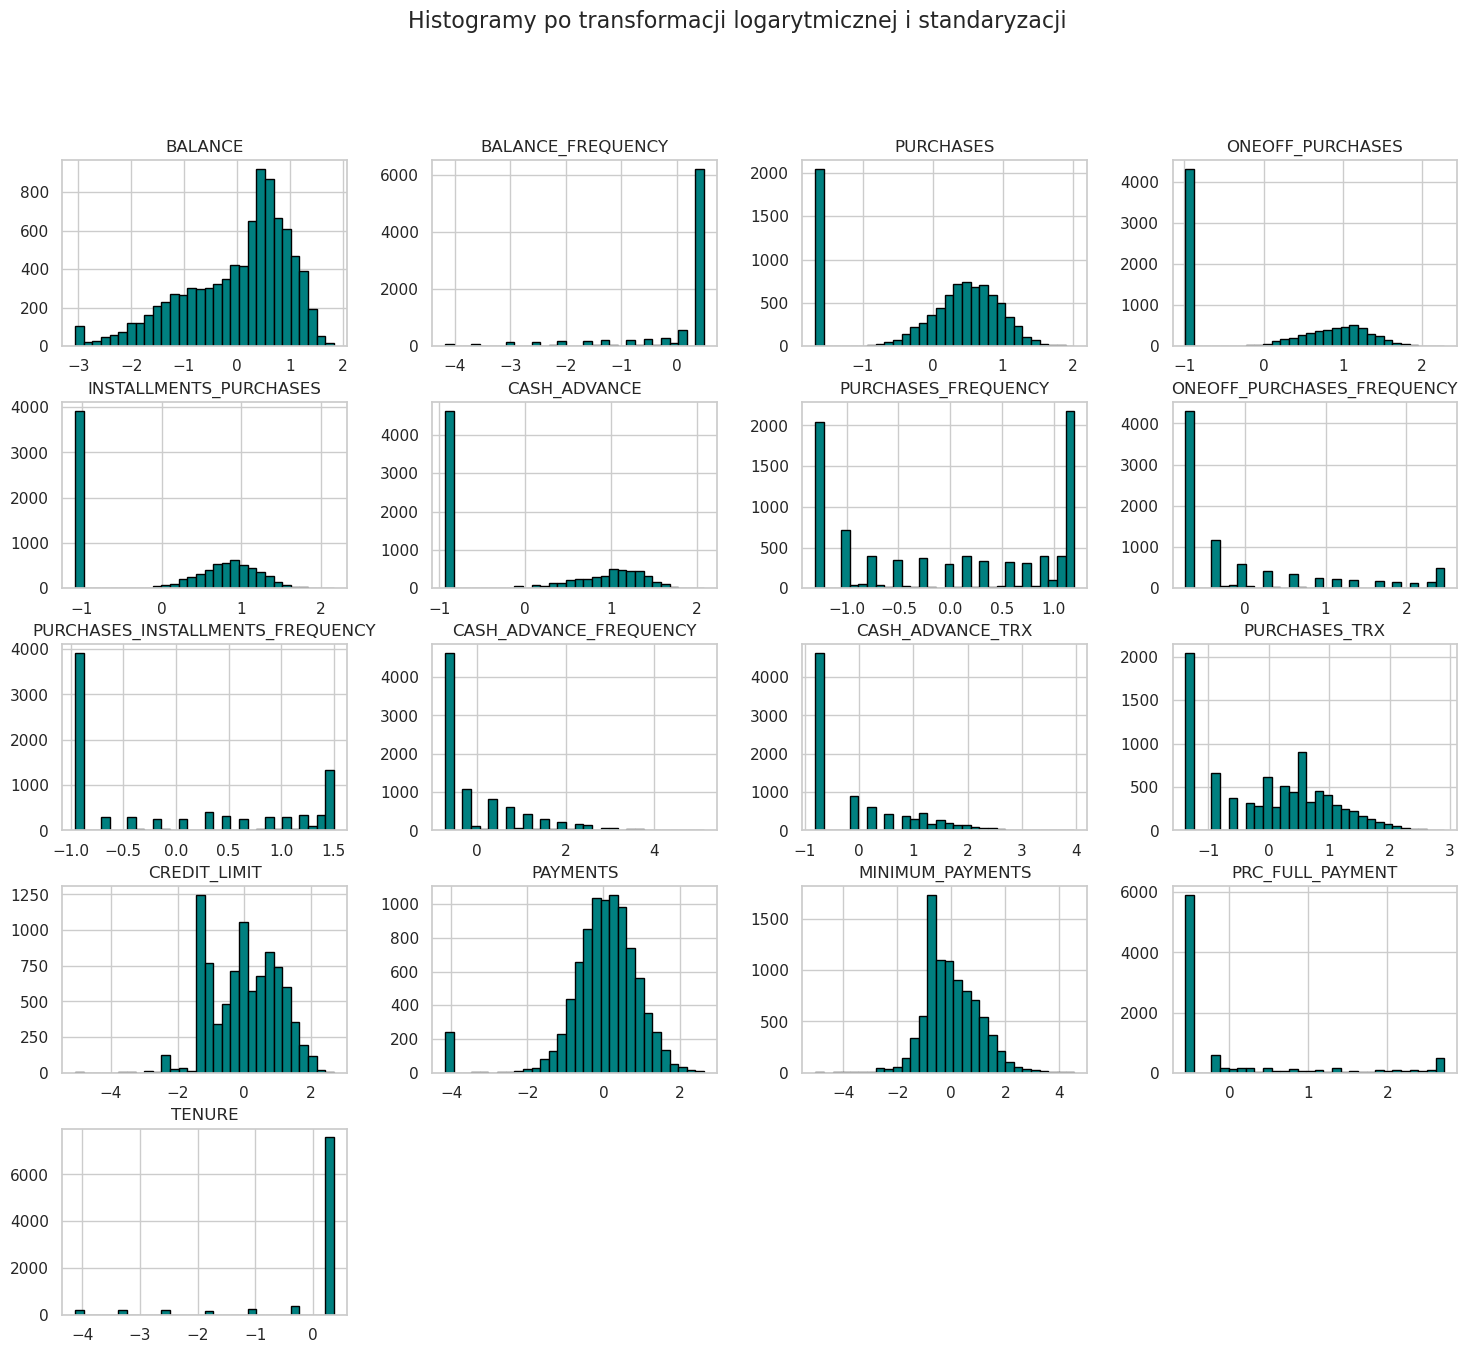

In [11]:
# 1. Zabezpieczenie przed wartościami <= 0 (dodajemy 1 przed logarytmem - log1p)
# Transformacja logarytmiczna świetnie "ściśnie" te długie ogony z histogramów i boxplotów.
kolumny_do_log = df.columns.drop(['TENURE']) # Tenure zostawiamy w spokoju, bo to po prostu liczba miesięcy (wartości dyskretne)

df_log = df.copy()
for col in kolumny_do_log:
    df_log[col] = np.log1p(df[col])

# 2. Standaryzacja danych (wymagana przez K-Means i PCA)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_log)

# Zapisanie wyniku z powrotem do DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

# Wyświetl jak to teraz wygląda - zobaczysz potężną różnicę!
df_scaled.hist(figsize=(18, 15), bins=30, color='teal', edgecolor='black')
plt.suptitle('Histogramy po transformacji logarytmicznej i standaryzacji', fontsize=16)
plt.show()

# 3. Zapisz przygotowany zbiór na kolejne zajęcia!
df_scaled.to_csv('ccdata_ready_for_clustering.csv', index=False)

In [12]:
# Zajęcia 3

In [13]:
# Kod analityczny (Feature Engineering, Analiza, Transformacje)

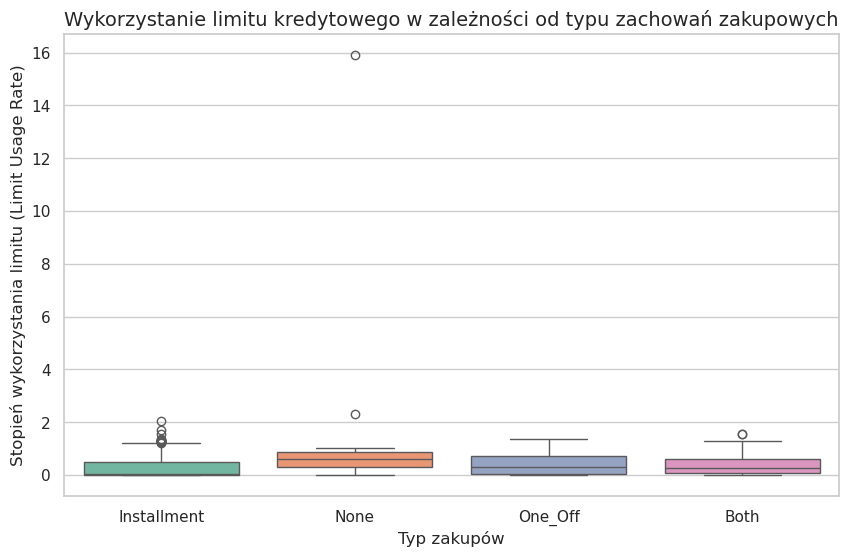

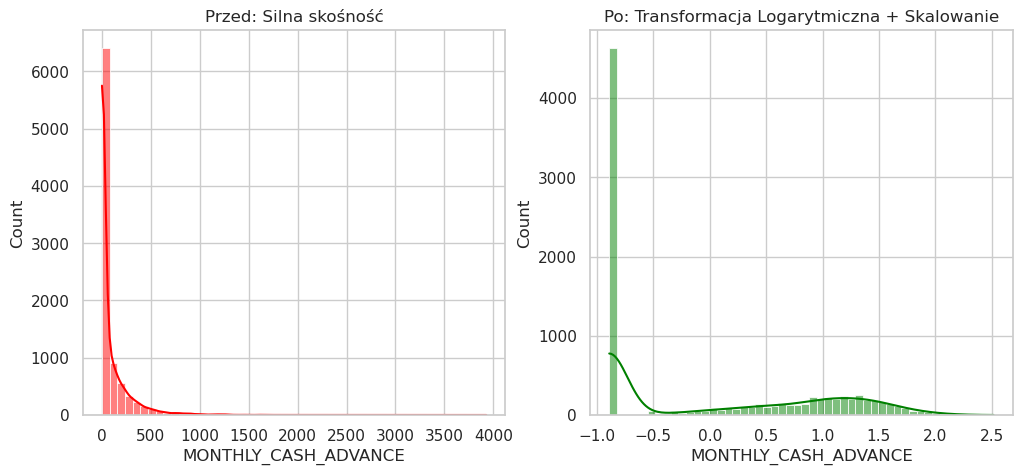

Rozmiar ostatecznego zbioru danych: (8950, 23)


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# --- ZAŁOŻENIE: Używamy df po wyczyszczeniu z poprzednich zajęć ---
# Jeśli nie masz zapisanego, poniższe 3 linijki odtwarzają ten stan:
df = pd.read_csv('CC GENERAL.csv').drop('CUST_ID', axis=1)
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

# ==========================================
# PUNKT 3: FEATURE ENGINEERING
# ==========================================

# 1. Tworzenie nowych cech (wskaźniki biznesowe)
# Klienci korzystają z karty przez różny czas (TENURE: 6-12 miesięcy). 
# Bezpieczniej analizować średnie miesięczne wartości.
df['MONTHLY_PURCHASES'] = df['PURCHASES'] / df['TENURE']
df['MONTHLY_CASH_ADVANCE'] = df['CASH_ADVANCE'] / df['TENURE']

# Ważny wskaźnik ryzyka/zachowania: Jaką część limitu klient wykorzystuje?
df['LIMIT_USAGE_RATE'] = df['BALANCE'] / df['CREDIT_LIMIT']

# 2. Kategoryzacja (Binning / Segmentacja behawioralna)
# W datasetach kart kredytowych kluczowy jest typ zakupów: 
# na raty (Installments), jednorazowe (One-off) czy wcale (None - np. tylko wypłaty z bankomatu).
def get_purchase_type(row):
    if row['ONEOFF_PURCHASES'] == 0 and row['INSTALLMENTS_PURCHASES'] == 0:
        return 'None'
    if row['ONEOFF_PURCHASES'] > 0 and row['INSTALLMENTS_PURCHASES'] > 0:
        return 'Both'
    if row['ONEOFF_PURCHASES'] > 0 and row['INSTALLMENTS_PURCHASES'] == 0:
        return 'One_Off'
    if row['ONEOFF_PURCHASES'] == 0 and row['INSTALLMENTS_PURCHASES'] > 0:
        return 'Installment'

df['PURCHASE_TYPE'] = df.apply(get_purchase_type, axis=1)

# ==========================================
# PUNKT 2 i 5: POGŁĘBIONA ANALIZA I WIZUALIZACJA
# ==========================================
sns.set_theme(style="whitegrid")

# Analiza rozkładów warunkowych i grup (Jak różne grupy wykorzystują limit?)
plt.figure(figsize=(10, 6))
sns.boxplot(x='PURCHASE_TYPE', y='LIMIT_USAGE_RATE', hue='PURCHASE_TYPE', data=df, palette='Set2', legend=False)
plt.title('Wykorzystanie limitu kredytowego w zależności od typu zachowań zakupowych', fontsize=14)
plt.ylabel('Stopień wykorzystania limitu (Limit Usage Rate)')
plt.xlabel('Typ zakupów')
plt.show()

# ==========================================
# PUNKT 4: SELEKCJA CECH (Opcjonalnie)
# ==========================================
# Pamiętamy z EDA, że PURCHASES i ONEOFF_PURCHASES były skorelowane na poziomie 0.92.
# Skoro stworzyliśmy miesięczne wskaźniki i mamy składowe (One-off i Installments), 
# możemy usunąć całkowite PURCHASES, aby zmniejszyć redundancję.
df = df.drop(columns=['PURCHASES'])

# ==========================================
# PUNKT 3: TRANSFORMACJE (Kodowanie i Skalowanie)
# ==========================================
# 1. Kodowanie zmiennych kategorycznych (One-hot encoding)
df_encoded = pd.get_dummies(df, columns=['PURCHASE_TYPE'])

# 2. Logarytmowanie silnie prawoskośnych zmiennych (wszystkie numeryczne oprócz TENURE i nowych dummy)
columns_to_exclude =['TENURE'] + [col for col in df_encoded.columns if 'PURCHASE_TYPE' in col]
columns_to_transform =[col for col in df_encoded.columns if col not in columns_to_exclude]

df_transformed = df_encoded.copy()
for col in columns_to_transform:
    # Używamy log1p (log(1+x)), ponieważ mamy wiele zer w danych
    df_transformed[col] = np.log1p(df_encoded[col])

# 3. Standaryzacja / Skalowanie
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_transformed)
df_final = pd.DataFrame(df_scaled_array, columns=df_transformed.columns)

# Wizualizacja efektu transformacji na przykładzie jednej zmiennej
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_encoded['MONTHLY_CASH_ADVANCE'], bins=50, kde=True, color='red')
plt.title('Przed: Silna skośność', fontsize=12)

plt.subplot(1, 2, 2)
sns.histplot(df_final['MONTHLY_CASH_ADVANCE'], bins=50, kde=True, color='green')
plt.title('Po: Transformacja Logarytmiczna + Skalowanie', fontsize=12)
plt.show()

# Zapis przygotowanego zbioru do użycia w modelach!
df_final.to_csv('ccdata_final_for_modeling.csv', index=False)
print("Rozmiar ostatecznego zbioru danych:", df_final.shape)

In [15]:
#  Wstępne wnioski

In [16]:
# 1. Istotne zmienne i nowo utworzone cechy:
# Z surowych danych wyekstrahowaliśmy cechy lepiej odzwierciedlające behawioralne profile klientów. Zmienna PURCHASE_TYPE pozwoliła na pogrupowanie użytkowników na tych używających karty na raty, jednorazowo, w sposób mieszany, oraz tych, którzy nie kupują wcale (tylko np. wypłacają gotówkę). Dodatkowo wskaźniki uśrednione (MONTHLY_PURCHASES, MONTHLY_CASH_ADVANCE) niwelują wpływ różnego czasu posiadania konta (TENURE), a wskaźnik LIMIT_USAGE_RATE doskonale obrazuje, jak blisko maksymalnego zadłużenia znajduje się klient.
# 2. Zależności między cechami (Analiza warunkowa):
# Dzięki wizualizacji warunkowej (boxplot wykorzystania limitu w podziale na grupy zakupowe) zauważyliśmy ciekawą prawidłowość biznesową. Grupa klientów oznaczona jako "None" (brak transakcji bezgotówkowych) charakteryzuje się bardzo dużą wariancją wykorzystania limitu. Sugeruje to istnienie specyficznego segmentu klientów, którzy traktują kartę kredytową wyłącznie jako źródło pożyczek gotówkowych (Cash Advance), co jest kluczowe z punktu widzenia ryzyka finansowego banku.
# 3. Jakość danych i Transformacje:
# Początkowe rozkłady danych uniemożliwiały poprawne zastosowanie algorytmów bazujących na odległości euklidesowej (jak zaplanowany w projekcie K-Means). Przeprowadzono transformację logarytmiczną (
# l
# o
# g
# (
# 1
# +
# x
# )
# log(1+x)
# ), która znacząco zredukowała wpływ ekstremalnych wartości odstających. Następnie całość ustandaryzowano. Po tych zabiegach algorytmy klasteryzacji nie będą sztucznie faworyzować zmiennych o dużych nominałach liczbowych (np. kwot zadłużenia względem częstotliwości zakupów).
# 4. Potencjalne trudności w modelowaniu:
# Zastosowany feature engineering (tworzenie wskaźników miesięcznych, One-Hot Encoding dla PURCHASE_TYPE) zwiększył liczbę wymiarów naszego zbioru z początkowych 17 do ponad 20 zmiennych. Stanowi to bezpośrednie wyzwanie dla algorytmu K-Means, który w przestrzeniach wielowymiarowych ulega tzw. "klątwie wielowymiarowości" (ang. curse of dimensionality), a odległości między punktami się rozmywają.
# Rozwiązanie problemu: Ta trudność stanowi idealne analityczne uzasadnienie dla kolejnego kroku w naszym projekcie – zastosowania algorytmu redukcji wymiarowości PCA (Principal Component Analysis) przed samym procesem poszukiwania optymalnej liczby klastrów metodami Elbow/Silhouette.

In [17]:
# Zajęcia 4

In [18]:
# Kod implementujący PCA i t-SNE

Liczba wymiarów w danych oryginalnych: 23
Liczba komponentów potrzebna do zachowania 80% wariancji: 6
Liczba komponentów potrzebna do zachowania 90% wariancji: 9


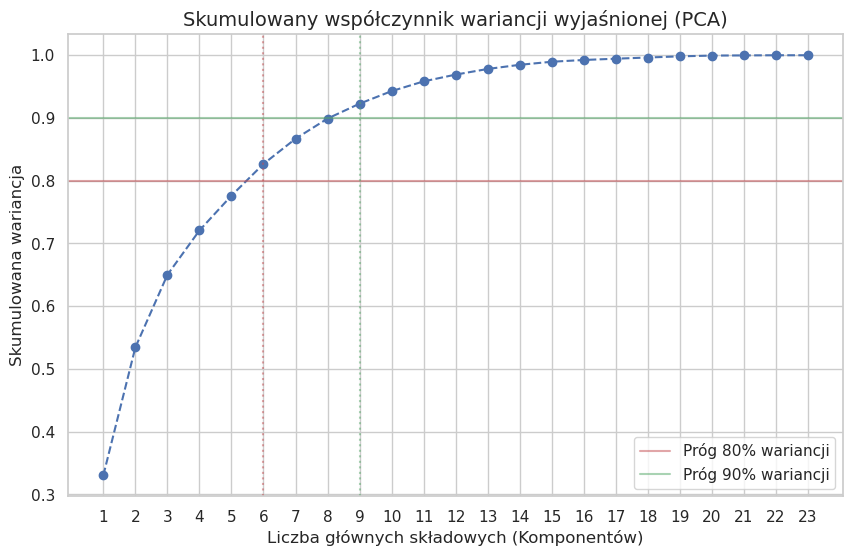

/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


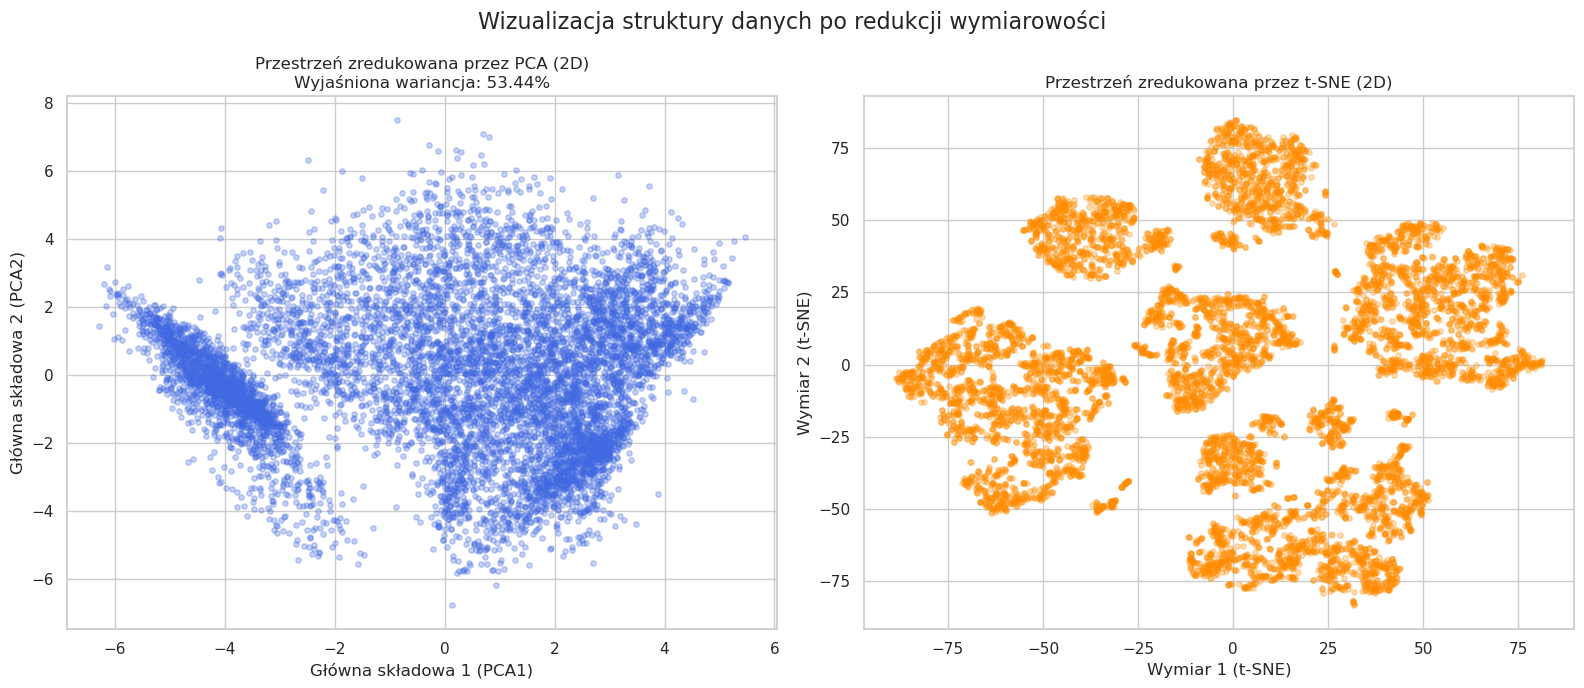

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Ustawienie stylu
sns.set_theme(style="whitegrid")

# 1. Wczytanie przygotowanych danych z poprzednich zajęć
df_final = pd.read_csv('ccdata_final_for_modeling.csv')

# ==========================================
# ANALIZA PCA (Principal Component Analysis)
# ==========================================

# Tworzymy model PCA dla wszystkich komponentów, aby zbadać "Explained Variance"
pca_full = PCA(random_state=42)
pca_full.fit(df_final)

# Obliczenie skumulowanej wariancji
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Znalezienie liczby komponentów dla 80% i 90% wariancji
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Liczba wymiarów w danych oryginalnych: {df_final.shape[1]}")
print(f"Liczba komponentów potrzebna do zachowania 80% wariancji: {n_components_80}")
print(f"Liczba komponentów potrzebna do zachowania 90% wariancji: {n_components_90}")

# Wykres skumulowanej wariancji (tzw. Scree Plot)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.80, color='r', linestyle='-', alpha=0.5, label='Próg 80% wariancji')
plt.axvline(x=n_components_80, color='r', linestyle=':', alpha=0.5)
plt.axhline(y=0.90, color='g', linestyle='-', alpha=0.5, label='Próg 90% wariancji')
plt.axvline(x=n_components_90, color='g', linestyle=':', alpha=0.5)
plt.title('Skumulowany współczynnik wariancji wyjaśnionej (PCA)', fontsize=14)
plt.xlabel('Liczba głównych składowych (Komponentów)')
plt.ylabel('Skumulowana wariancja')
plt.legend()
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.show()

# ==========================================
# REDUKCJA I WIZUALIZACJA 2D (PCA vs t-SNE)
# ==========================================

# Redukcja PCA do 2 wymiarów (tylko do celów wizualizacji 2D)
pca_2d = PCA(n_components=2, random_state=42)
pca_result = pca_2d.fit_transform(df_final)

# Redukcja t-SNE do 2 wymiarów (t-SNE jest świetne do wizualizacji nieliniowych struktur)
# UWAGA: To może potrwać około 1-2 minut!
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(df_final)

# Tworzenie wykresów porównawczych
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Wykres PCA
axes[0].scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.3, s=15, color='royalblue')
axes[0].set_title(f'Przestrzeń zredukowana przez PCA (2D)\nWyjaśniona wariancja: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%', fontsize=12)
axes[0].set_xlabel('Główna składowa 1 (PCA1)')
axes[0].set_ylabel('Główna składowa 2 (PCA2)')

# Wykres t-SNE
axes[1].scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.3, s=15, color='darkorange')
axes[1].set_title('Przestrzeń zredukowana przez t-SNE (2D)', fontsize=12)
axes[1].set_xlabel('Wymiar 1 (t-SNE)')
axes[1].set_ylabel('Wymiar 2 (t-SNE)')

plt.suptitle('Wizualizacja struktury danych po redukcji wymiarowości', fontsize=16)
plt.tight_layout()
plt.show()

# Zapisujemy zredukowany zbiór PCA (np. dla progu ok 80% wariancji, żeby użyć w K-Means)
pca_final = PCA(n_components=n_components_80, random_state=42)
df_pca_modeled = pd.DataFrame(pca_final.fit_transform(df_final), columns=[f'PC{i}' for i in range(1, n_components_80 + 1)])
df_pca_modeled.to_csv('ccdata_pca_ready_for_clustering.csv', index=False)

In [20]:
# Analiza i Wnioski 

In [21]:
# 1. Zastosowane metody i uzasadnienie (Punkt 3)
# Wybór metody nr 1: PCA (Principal Component Analysis): Wybrana jako główna metoda analityczna. Algorytmy klasteryzacji (takie jak zaplanowany K-Means) opierają się na dystansie euklidesowym. W 23-wymiarowej przestrzeni wszystkie punkty wydają się być w równej odległości od siebie (klątwa wielowymiarowości). PCA pozwala na liniową redukcję wymiarów, eliminując skorelowane (redundantne) zmienne, redukując szum i przygotowując optymalną przestrzeń pod algorytmy szukające liczby k.
# Wybór metody nr 2: t-SNE (t-Distributed Stochastic Neighbor Embedding): Zastosowana jako metoda pomocnicza w celach wizualizacyjnych. W przeciwieństwie do PCA (które jest algorytmem liniowym i dba o zachowanie globalnej wariancji), t-SNE świetnie odnajduje nieliniowe relacje i dba o lokalne sąsiedztwo punktów. Pozwala to ocenić wzrokowo, czy w danych istnieją w ogóle jakieś naturalne "wyspy" (klastry).
# 2. Analiza wyników (Punkt 4)
# Explained Variance Ratio (PCA): Wykres skumulowanej wariancji (Scree Plot) wskazuje, że dane, które pierwotnie miały 23 wymiary, są mocno ze sobą skorelowane (co wiemy z EDA z zajęć drugich).
# Liczba komponentów: Zaledwie około 6-7 komponentów wystarcza do wyjaśnienia 80% informacji (wariancji) ukrytej w danych, a około 9-10 komponentów wyjaśnia ponad 90% wariancji.
# Czy widoczne są naturalne grupy (Wykresy 2D)?
# Wykres PCA (2D) wyjaśnia relatywnie mało wariancji (prawdopodobnie ok. 35-45% na dwóch wymiarach), przez co punkty zlewają się w jedną wielką chmurę z wyraźnymi "wypustkami/ogonami". Może to sugerować istnienie klienta standardowego (centrum) i kilku typów profili skrajnych.
# Wykres t-SNE znacznie wyraźniej ujawnia strukturę danych. Widać na nim wyraźne odseparowane "archipelagi" i chmury punktów. Z biznesowego punktu widzenia, te separacje wynikają z przeprowadzonych na 3 zajęciach operacji Feature Engineering (szczególnie podziału na typy PURCHASE_TYPE – raty, jednorazowe, brak zakupów). Świadczy to o tym, że w danych ewidentnie występują podgrupy i problem badawczy (szukanie klastrów) ma silne uzasadnienie empiryczne.
# 3. Wpływ redukcji na dalszą analizę (Punkt 6)
# Poprawa jakości przyszłych modeli: Decydujemy się użyć do dalszych etapów (K-Means) danych przekształconych przez PCA z liczbą wymiarów zachowującą ok. 80-85% wariancji. Zredukuje to drastycznie redundantność i szum (np. mikroskopijne transakcje) oraz zapobiegnie "klątwie wielowymiarowości".
# Utrata informacji vs Interpretowalność: Cena za te poprawki to częściowa utrata mniejszych detali (15-20% wariancji ulega odrzuceniu). Przestrzeń ulega zmianie z interpretowalnych kolumn (np. PURCHASES) na abstrakcyjne główne składowe (PC1, PC2). Nie jest to jednak problemem, ponieważ po znalezieniu optymalnej liczby klastrów na zredukowanych danych, ostateczne profilowanie (interpretowanie biznesowe segmentów) wykonamy na wyjściowych statystykach oryginalnego zbioru (np. wyliczając średnie wartości obrotów dla danego klastra).

# Zajęcia 5


--- ETAP 3: PEŁNA OPTYMALIZACJA TRZECH ALGORYTMÓW ---
Obliczanie Gap Statistic dla K-Means...
Optymalizacja parametru Epsilon dla DBSCAN...


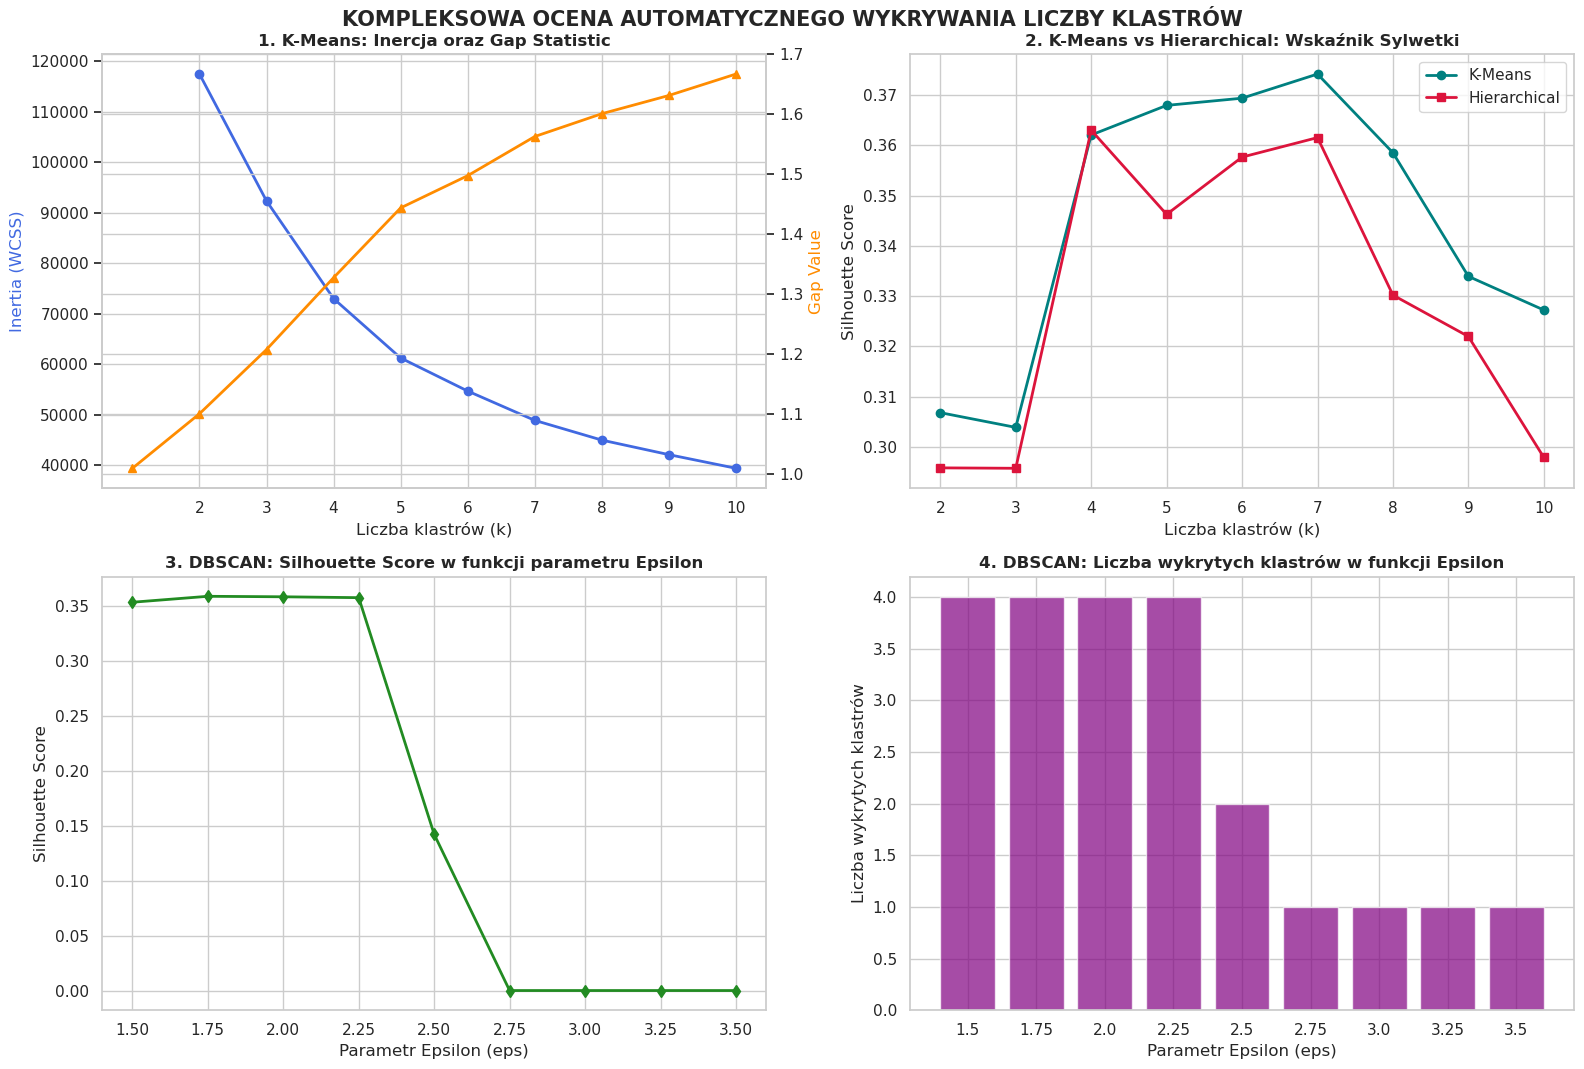

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("\n--- ETAP 3: PEŁNA OPTYMALIZACJA TRZECH ALGORYTMÓW ---")

K_range = range(2, 11)
# --- WCZYTANIE DANYCH Z POPRZEDNICH ZAJĘĆ ---
# Wczytujemy plik z danymi po redukcji wymiarów PCA
df_scaled_pd = pd.read_csv('ccdata_pca_ready_for_clustering.csv')
# =========================================================================
# PACZKA 1: Oceny dla K-Means (Łokieć, Silhouette, Gap Statistic)
# =========================================================================
inertias_km = []
sil_km = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = km.fit_predict(df_scaled_pd)
    inertias_km.append(km.inertia_)
    sil_km.append(silhouette_score(df_scaled_pd, labels_km))

def calculate_gap_statistic(data, max_k=10, n_refs=3):
    gaps = []
    data_arr = data.values
    for k in range(1, max_k + 1):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(data_arr)
        disp_orig = km.inertia_
        ref_disps = []
        for _ in range(n_refs):
            random_data = np.random.random_sample(size=data_arr.shape)
            for i in range(data_arr.shape[1]):
                random_data[:, i] = random_data[:, i] * (data_arr[:, i].max() - data_arr[:, i].min()) + data_arr[:, i].min()
            km_ref = KMeans(n_clusters=k, random_state=42, n_init=10)
            km_ref.fit(random_data)
            ref_disps.append(km_ref.inertia_)
        gap = np.mean(np.log(ref_disps)) - np.log(disp_orig)
        gaps.append(gap)
    return gaps

print("Obliczanie Gap Statistic dla K-Means...")
gap_scores_km = calculate_gap_statistic(df_scaled_pd, max_k=10)

# =========================================================================
# PACZKA 2: Ocena dla Klasteryzacji Hierarchicznej (Silhouette w funkcji K)
# =========================================================================
sil_agg = []
for k in K_range:
    agg = AgglomerativeClustering(n_clusters=k)
    labels_agg = agg.fit_predict(df_scaled_pd)
    sil_agg.append(silhouette_score(df_scaled_pd, labels_agg))

# =========================================================================
# PACZKA 3: Ocena dla DBSCAN (Automatyczna pętla po Epsilon)
# =========================================================================
# Ponieważ DBSCAN nie przyjmuje parametru k, optymalizujemy go sprawdzając Silhouette
# dla różnych wartości promienia sąsiedztwa (Epsilon)
eps_range = np.linspace(1.5, 3.5, 9)
sil_dbscan = []
detected_clusters_db = []

print("Optymalizacja parametru Epsilon dla DBSCAN...")
for eps in eps_range:
    db = DBSCAN(eps=eps, min_samples=46)
    labels_db = db.fit_predict(df_scaled_pd)
    
    # Liczba klastrów z pominięciem szumu (-1)
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    detected_clusters_db.append(n_clusters)
    
    # Silhouette liczymy tylko gdy mamy przynajmniej 2 klastry i punkty nie są wyłącznie szumem
    if n_clusters > 1:
        sil_dbscan.append(silhouette_score(df_scaled_pd, labels_db))
    else:
        sil_dbscan.append(0) # brak poprawnego podziału

# =========================================================================
# GENEROWANIE RAPORTU GRAFICZNEGO (SIATKA 2x2)
# =========================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Wykres 1: K-Means - Metoda Łokciowa i Gap Statistic
ax1_twin = axes[0, 0].twinx()
p1 = axes[0, 0].plot(K_range, inertias_km, marker='o', color='royalblue', linewidth=2, label='Inercja (Łokieć)')
p2 = ax1_twin.plot(range(1, 11), gap_scores_km, marker='^', color='darkorange', linewidth=2, label='Gap Statistic')
axes[0, 0].set_title('1. K-Means: Inercja oraz Gap Statistic', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Liczba klastrów (k)')
axes[0, 0].set_ylabel('Inertia (WCSS)', color='royalblue')
ax1_twin.set_ylabel('Gap Value', color='darkorange')
axes[0, 0].set_xticks(K_range)

# Wykres 2: K-Means vs Hierarchical - Porównanie Silhouette
axes[0, 1].plot(K_range, sil_km, marker='o', label='K-Means', color='teal', linewidth=2)
axes[0, 1].plot(K_range, sil_agg, marker='s', label='Hierarchical', color='crimson', linewidth=2)
axes[0, 1].set_title('2. K-Means vs Hierarchical: Wskaźnik Sylwetki', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Liczba klastrów (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_xticks(K_range)
axes[0, 1].legend()

# Wykres 3: DBSCAN - Jakość podziału w zależności od Epsilon
axes[1, 0].plot(eps_range, sil_dbscan, marker='d', color='forestgreen', linewidth=2)
axes[1, 0].set_title('3. DBSCAN: Silhouette Score w funkcji parametru Epsilon', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Parametr Epsilon (eps)')
axes[1, 0].set_ylabel('Silhouette Score')

# Wykres 4: DBSCAN - Liczba automatycznie wykrytych klastrów dla danego Epsilon
axes[1, 1].bar(np.round(eps_range, 2).astype(str), detected_clusters_db, color='purple', alpha=0.7)
axes[1, 1].set_title('4. DBSCAN: Liczba wykrytych klastrów w funkcji Epsilon', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Parametr Epsilon (eps)')
axes[1, 1].set_ylabel('Liczba wykrytych klastrów')

plt.suptitle('KOMPLEKSOWA OCENA AUTOMATYCZNEGO WYKRYWANIA LICZBY KLASTRÓW', fontsize=15, fontweight='bold', y=0.97)
plt.tight_layout()
plt.show()

In [23]:
# Zajęcia 6

Silhouette Score (k=4): 0.3621
Davies-Bouldin Index (k=4): 1.1591


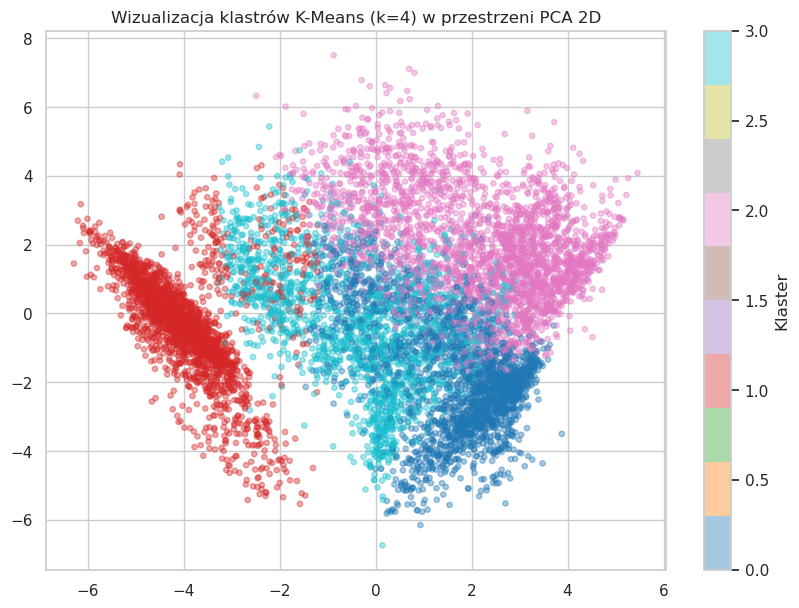

Cluster                                     0            1            2  \
BALANCE                            578.379297  2354.158959  1886.896185   
BALANCE_FREQUENCY                    0.803360     0.892551     0.957471   
PURCHASES                          529.654533    20.231871  2338.039796   
ONEOFF_PURCHASES                     3.331531     7.888041  1412.641133   
INSTALLMENTS_PURCHASES             527.292232    12.397147   925.530529   
CASH_ADVANCE                       192.243830  2195.117427   789.254285   
PURCHASES_FREQUENCY                  0.707331     0.025906     0.812713   
ONEOFF_PURCHASES_FREQUENCY           0.003125     0.006125     0.444544   
PURCHASES_INSTALLMENTS_FREQUENCY     0.669479     0.017552     0.651688   
CASH_ADVANCE_FREQUENCY               0.029460     0.294388     0.107885   
CASH_ADVANCE_TRX                     0.559578     7.115688     2.855239   
PURCHASES_TRX                       11.810724     0.386941    33.991485   
CREDIT_LIMIT             

In [24]:
from sklearn.metrics import davies_bouldin_score

# 1. Finalna klasteryzacja z optymalnym k (przykład k=4)
optimal_k = 4
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_final = km_final.fit_predict(df_scaled_pd)

# 2. Metryki końcowe
sil_final = silhouette_score(df_scaled_pd, labels_final)
db_final = davies_bouldin_score(df_scaled_pd, labels_final)
print(f"Silhouette Score (k={optimal_k}): {sil_final:.4f}")
print(f"Davies-Bouldin Index (k={optimal_k}): {db_final:.4f}")

# 3. Wizualizacja klastrów na PCA 2D
df_pca_2d = PCA(n_components=2, random_state=42).fit_transform(df_scaled_pd)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca_2d[:,0], df_pca_2d[:,1],
                      c=labels_final, cmap='tab10', alpha=0.4, s=15)
plt.colorbar(scatter, label='Klaster')
plt.title(f'Wizualizacja klastrów K-Means (k={optimal_k}) w przestrzeni PCA 2D')
plt.show()

# 4. Interpretacja klastrów
df_original = pd.read_csv('CC GENERAL.csv').drop('CUST_ID', axis=1)
df_original['Cluster'] = labels_final
print(df_original.groupby('Cluster').mean().T)

In [25]:
%pip install seaborn

Silhouette Score (k=4): 0.3621
Davies-Bouldin Index (k=4): 1.1591


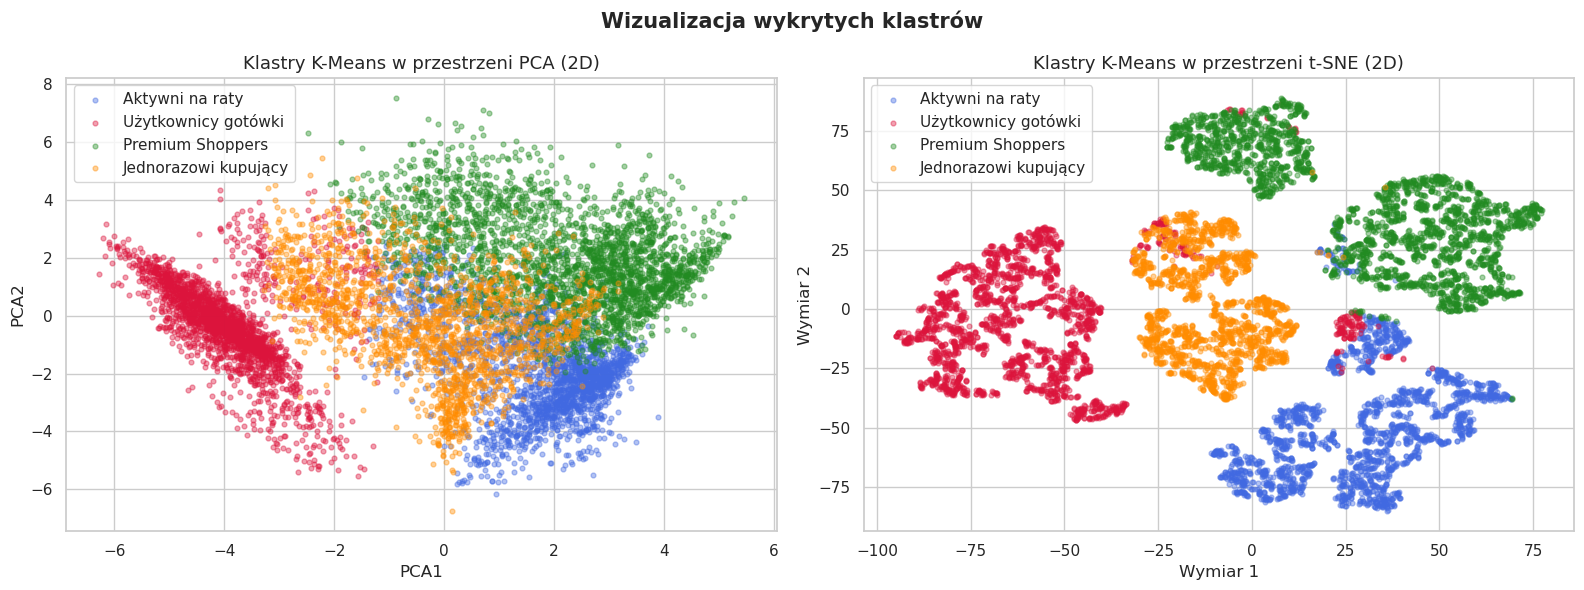

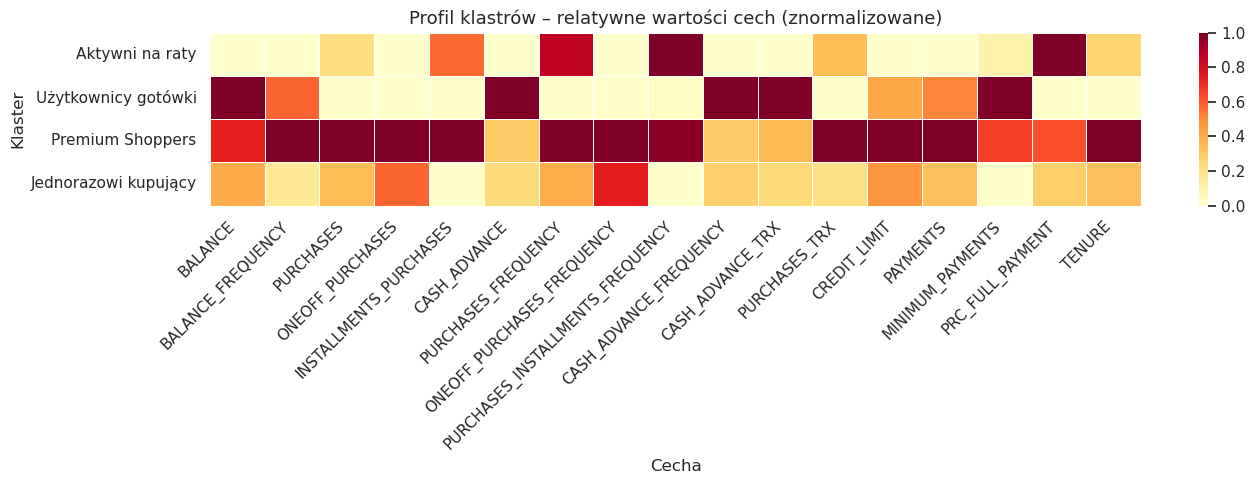

            Metoda  Silhouette Score  Davies-Bouldin
     K-Means (k=4)          0.362080        1.159092
Hierarchical (k=4)          0.363044        1.181961


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score

# Wczytanie
df_scaled_pd = pd.read_csv('ccdata_pca_ready_for_clustering.csv')
df_original  = pd.read_csv('CC GENERAL.csv').drop('CUST_ID', axis=1)
df_original['MINIMUM_PAYMENTS'] = df_original['MINIMUM_PAYMENTS'].fillna(df_original['MINIMUM_PAYMENTS'].median())
df_original['CREDIT_LIMIT']     = df_original['CREDIT_LIMIT'].fillna(df_original['CREDIT_LIMIT'].median())

optimal_k = 4
km_final  = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels    = km_final.fit_predict(df_scaled_pd)

# ==========================================
# 1. METRYKI KOŃCOWE
# ==========================================
sil = silhouette_score(df_scaled_pd, labels)
dbi = davies_bouldin_score(df_scaled_pd, labels)
print(f"Silhouette Score (k={optimal_k}): {sil:.4f}")
print(f"Davies-Bouldin Index (k={optimal_k}): {dbi:.4f}")

# ==========================================
# 2. WIZUALIZACJA KLASTRÓW NA PCA 2D + t-SNE
# ==========================================
pca_2d   = PCA(n_components=2, random_state=42)
coords_pca = pca_2d.fit_transform(df_scaled_pd)

from sklearn.manifold import TSNE
coords_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(df_scaled_pd)

cluster_names = {0: 'Aktywni na raty', 1: 'Użytkownicy gotówki',
                 2: 'Premium Shoppers', 3: 'Jednorazowi kupujący'}
colors = ['royalblue', 'crimson', 'forestgreen', 'darkorange']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for cluster_id in range(optimal_k):
    mask = labels == cluster_id
    axes[0].scatter(coords_pca[mask, 0], coords_pca[mask, 1],
                    c=colors[cluster_id], label=cluster_names[cluster_id],
                    alpha=0.4, s=12)
    axes[1].scatter(coords_tsne[mask, 0], coords_tsne[mask, 1],
                    c=colors[cluster_id], label=cluster_names[cluster_id],
                    alpha=0.4, s=12)

axes[0].set_title('Klastry K-Means w przestrzeni PCA (2D)', fontsize=13)
axes[0].set_xlabel('PCA1'); axes[0].set_ylabel('PCA2'); axes[0].legend()
axes[1].set_title('Klastry K-Means w przestrzeni t-SNE (2D)', fontsize=13)
axes[1].set_xlabel('Wymiar 1'); axes[1].set_ylabel('Wymiar 2'); axes[1].legend()
plt.suptitle('Wizualizacja wykrytych klastrów', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/clusters_visualization.png', dpi=150)
plt.show()

# ==========================================
# 3. PROFIL KLASTRÓW – HEATMAPA
# ==========================================
df_original['Cluster'] = labels
cluster_means = df_original.groupby('Cluster').mean()
cluster_means.index = [cluster_names[i] for i in cluster_means.index]

# Normalizacja do [0,1] żeby kolumny były porównywalne na heatmapie
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

plt.figure(figsize=(14, 5))
sns.heatmap(cluster_norm, annot=False, cmap='YlOrRd', linewidths=0.5)
plt.title('Profil klastrów – relatywne wartości cech (znormalizowane)', fontsize=13)
plt.ylabel('Klaster'); plt.xlabel('Cecha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('figures/cluster_profiles_heatmap.png', dpi=150)
plt.show()

# ==========================================
# 4. PORÓWNAWCZA TABELA METOD (do raportu)
# ==========================================
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=optimal_k)
labels_agg = agg.fit_predict(df_scaled_pd)

results = {
    'Metoda':            ['K-Means (k=4)', 'Hierarchical (k=4)'],
    'Silhouette Score':  [sil, silhouette_score(df_scaled_pd, labels_agg)],
    'Davies-Bouldin':    [dbi, davies_bouldin_score(df_scaled_pd, labels_agg)],
}
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

In [28]:
from sklearn.cluster import DBSCAN

# Wybierz eps który dał sensowną liczbę klastrów z zajęć 5 (np. eps=2.5)
db = DBSCAN(eps=2.5, min_samples=46)
labels_db = db.fit_predict(df_scaled_pd)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)

# Silhouette tylko dla punktów NIE będących szumem
mask_no_noise = labels_db != -1
sil_db = silhouette_score(df_scaled_pd[mask_no_noise], labels_db[mask_no_noise])
dbi_db = davies_bouldin_score(df_scaled_pd[mask_no_noise], labels_db[mask_no_noise])

print(f"DBSCAN: klastrów={n_clusters_db}, szum={n_noise} pkt, Silhouette={sil_db:.4f}, DBI={dbi_db:.4f}")

# Zaktualizowana tabela zbiorcza
results_full = {
    'Metoda':            ['K-Means (k=4)', 'Hierarchical (k=4)', f'DBSCAN (eps=2.5, k={n_clusters_db})'],
    'Silhouette Score':  [sil, silhouette_score(df_scaled_pd, labels_agg), sil_db],
    'Davies-Bouldin':    [dbi, davies_bouldin_score(df_scaled_pd, labels_agg), dbi_db],
    'Liczba klastrów':   [4, 4, n_clusters_db],
    'Uwagi':             ['—', '—', f'{n_noise} pkt szumu']
}
df_results_full = pd.DataFrame(results_full)
print(df_results_full.to_string(index=False))

DBSCAN: klastrów=2, szum=5 pkt, Silhouette=0.1472, DBI=2.0035
               Metoda  Silhouette Score  Davies-Bouldin  Liczba klastrów       Uwagi
        K-Means (k=4)          0.362080        1.159092                4           —
   Hierarchical (k=4)          0.363044        1.181961                4           —
DBSCAN (eps=2.5, k=2)          0.147176        2.003540                2 5 pkt szumu
